# 04 — Classification Model: Predicting Displacement Risk
**Project:** Charlotte NPA Housing Affordability Analysis  
**Target Variable:** `displacement_risk` (binary: 0 = Stable, 1 = At Risk)  
**Working dataset:** 444 NPAs from `npa_features_model`

## Policy Interpretation (Context from Regression)

While the regression model failed to reliably predict exact home prices ($R^2 = 0.06$), the classification output shows that the underlying signals are still highly effective for displacement screening. By applying the Fannie Mae 36% DTI test as a post-hoc threshold to predicted prices, we achieved a 77.5% accuracy rate, proving the regression-derived approach remains a viable tool for triage.
**This notebook tests whether direct classification of `displacement_risk` performs even better.** Predicting the binary label directly should be easier than predicting an exact dollar amount and then thresholding, because the model can focus all its capacity on learning the boundary that matters.

### Executive Summary
*This notebook implements a "Triage Tool" to identify neighborhoods at risk of displacement. By shifting from noisy price prediction to direct binary classification, we achieved a **75% stable accuracy** across multiple validation splits, providing a robust tool for policy intervention.*

* **Model Performance:** The Random Forest Classifier consistently outperformed 6 other candidates, achieving 75% accuracy (mean across 10 random seeds).
* **Primary Drivers:** The most critical predictors of displacement are **Household Income**, **Housing Size (sqft)**, and **Absenteeism rates**.
* **Reliability:** The model successfully passed a rigorous stability check, confirming that our identification of "At Risk" neighborhoods is based on stable demographic patterns rather than statistical noise.

## Findings Summary (read this first)

This notebook compares **6 classification models** to predict `displacement_risk` directly from 8 NPA-level demographic and economic features. Each model is fit on the same 80/20 stratified train-test split, evaluated using 5-fold stratified cross-validation on training data only, and the winning specification is subjected to a **multi-seed stability check** across 10 random splits.

### Why this notebook is structured the way it is
Lessons applied from the regression work:
1. **Hardcoded leakage-free feature list.** The table contains engineered columns (`cost_to_affordable_ratio`, `home_sales_price`, `rent_to_income_ratio`) that are literally part of the formula used to compute `displacement_risk`. If used as features they would reverse-engineer the target. We list features explicitly to keep them out.
2. **Stratified splits and stratified CV.** The class balance is 271 Stable / 173 At Risk (39% positive). Stratification preserves this balance across train/test/CV folds.
3. **Multi-seed stability check.** Single-split accuracy is not enough; we test the winner across 10 random states.
4. **Wide candidate lineup.** Six classifiers spanning linear, distance-based, tree, and ensemble methods.

### What we test
| Model | Why it earns a slot |
|---|---|
| Logistic Regression (scaled) | Interpretable baseline with coefficients and odds ratios |
| Logistic L1 (Lasso) | Automatic feature selection |
| Logistic L2 (Ridge) | Regularization for partial multicollinearity |
| KNN k=10 (scaled) | Nonparametric distance-based comparison |
| Decision Tree | Interpretable single-model nonparametric |
| Random Forest | Ensemble of trees, captures interactions |
| Gradient Boosting | Sequential ensemble, often best raw performance |

### Baseline to beat
Always predicting the majority class (Stable) gets **61% accuracy**. Any meaningful model should clear 65% with stable performance across seeds.

## Notebook structure
1. Preflight check
2. Load model-ready table
3. Define feature sets (hardcoded, leakage-free)
4. Stratified train/test split with median imputation
5. Reusable evaluation function
6. Build all 7 candidate classifiers
7. Fit and compare on the test set
8. Multi-seed stability check on the winner
9. Confusion matrix and classification report
10. ROC curve and Precision-Recall curve
11. Feature importance and coefficient interpretation
12. Headline figure for the presentation
13. Save outputs to database

In [39]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

# Plot styling for presentation-grade figures
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
})
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Project palette for consistent visuals
PALETTE = {
    'stable': '#3B7BBF',     # steel blue
    'at_risk': '#C0392B',    # firebrick
    'neutral': '#7F8C8D',    # slate gray
    'accent': '#2C3E50',     # deep navy
    'highlight': '#F39C12',  # amber
    'soft': '#D5DBDB',       # light gray
}

base = os.path.abspath(os.path.join(os.getcwd(), '..'))
db_path = os.path.join(base, 'data', 'charlotte_housing.db')
print(f'Project root: {base}')
print(f'Database:     {db_path}')

Project root: c:\Users\juant\OneDrive\Desktop\Charlotte-NPA-Housing-Affordability-Analysis
Database:     c:\Users\juant\OneDrive\Desktop\Charlotte-NPA-Housing-Affordability-Analysis\data\charlotte_housing.db


## 1. Preflight Check

In [40]:
REQUIRED_TABLE = 'npa_features_model'
REQUIRED_COLUMNS = [
    'npa_id', 'home_sales_price', 'log_home_sales_price', 'displacement_risk',
    'tree_canopy_pct', 'bachelors_pct', 'water_consumption_gpd', 'median_rent',
    'absenteeism_pct', 'household_income', 'housing_size_sqft', 'voter_participation_pct'
]
MIN_EXPECTED_ROWS = 400

def preflight():
    if not os.path.exists(db_path):
        raise FileNotFoundError(f'Database not found at {db_path}.')
    print(f'[OK] Database file exists ({os.path.getsize(db_path) / 1024:.1f} KB)')

    conn = sqlite3.connect(db_path)
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()
    print(f'[OK] Tables in database: {tables}')

    if REQUIRED_TABLE not in tables:
        conn.close()
        raise RuntimeError(f'\nMissing required table. Run notebook 02 first.')
    print(f'[OK] Required table "{REQUIRED_TABLE}" exists')

    df_check = pd.read_sql(f'SELECT * FROM {REQUIRED_TABLE}', conn)
    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df_check.columns]
    if missing_cols:
        conn.close()
        raise RuntimeError(f'\nMissing columns: {missing_cols}')
    print(f'[OK] All {len(REQUIRED_COLUMNS)} required columns present')

    if len(df_check) < MIN_EXPECTED_ROWS:
        conn.close()
        raise RuntimeError(f'\nRow count too low: {len(df_check)}')
    print(f'[OK] Row count: {len(df_check)} NPAs')

    if sorted(df_check['displacement_risk'].dropna().unique().tolist()) != [0, 1]:
        conn.close()
        raise RuntimeError(f'\ndisplacement_risk is not binary.')
    print(f'[OK] displacement_risk is binary {{0, 1}}')

    class_counts = df_check['displacement_risk'].value_counts().sort_index()
    print(f'[OK] Class balance: Stable={class_counts[0]}, At Risk={class_counts[1]} '
          f'(positive class = {class_counts[1]/len(df_check)*100:.1f}%)')

    print('\nPreflight passed. Safe to proceed.')
    return conn

conn = preflight()

[OK] Database file exists (256.0 KB)
[OK] Tables in database: ['npa_features_model', 'home_sales_price', 'tree_canopy', 'education', 'water_consumption', 'rental_costs', 'absenteeism', 'household_income', 'housing_size', 'voter_participation', 'npa_features', 'regression_model_comparison', 'regression_test_predictions', 'regression_final_coefficients', 'regression_stability_check', 'classification_model_comparison', 'classification_stability_check', 'classification_test_predictions']
[OK] Required table "npa_features_model" exists
[OK] All 12 required columns present
[OK] Row count: 444 NPAs
[OK] displacement_risk is binary {0, 1}
[OK] Class balance: Stable=271, At Risk=173 (positive class = 39.0%)

Preflight passed. Safe to proceed.


## 2. Load model-ready table

In [41]:
df = pd.read_sql(f'SELECT * FROM {REQUIRED_TABLE}', conn)
print(f'Shape: {df.shape}')
df.head()

Shape: (444, 15)


,npa_id,home_sales_price,log_home_sales_price,displacement_risk,cost_to_affordable_ratio,rent_to_income_ratio,income_per_sqft,tree_canopy_pct,bachelors_pct,water_consumption_gpd,median_rent,absenteeism_pct,household_income,housing_size_sqft,voter_participation_pct
0,2,"488,364.0000",13.0988,1,1.1539,0.2001,43.6535,38.1000,35.2000,125.0000,"1,252.0000",33.0000,"75,084.0000","1,720.0000",31.6000
1,3,"667,092.0000",13.4107,1,1.0061,0.1921,41.9059,23.1000,85.4000,180.0000,"1,883.0000",6.6000,"117,630.0000","2,807.0000",27.4000
2,4,"1,493,043.0000",14.2163,1,1.0595,NaN,60.1253,59.5000,89.4000,260.0000,NaN,6.2000,"250,001.0000","4,158.0000",43.4000
3,5,"255,031.0000",12.4491,0,0.9133,0.2856,41.4552,41.0000,2.5000,135.0000,"1,179.0000",43.3000,"49,539.0000","1,195.0000",11.8000
4,6,"445,698.0000",13.0074,1,2.0860,0.3371,29.1368,34.8000,21.0000,120.0000,"1,065.0000",35.6000,"37,907.0000","1,301.0000",20.5000


## 3. Define feature sets — HARDCODED to prevent target leakage
**Critical for classification.** The `displacement_risk` label was engineered in notebook 02 from the formula:

```
displacement_risk = 1 if (home_sales_price × 0.80 × monthly_factor × 12) > (household_income × 0.36)
```

This means **`home_sales_price`, `log_home_sales_price`, `cost_to_affordable_ratio`, and `rent_to_income_ratio` are all directly part of the label's derivation** and must never be used as features. If included they would let the model reverse-engineer the label and produce artificially perfect accuracy.

We hardcode the feature list and verify it does not contain forbidden columns. The notebook will refuse to run if leakage is detected.

In [42]:
features_full = [
    'tree_canopy_pct', 'bachelors_pct', 'water_consumption_gpd', 'median_rent',
    'absenteeism_pct', 'household_income', 'housing_size_sqft', 'voter_participation_pct'
]

FORBIDDEN = [
    'home_sales_price', 'log_home_sales_price',
    'cost_to_affordable_ratio', 'rent_to_income_ratio',
    'income_per_sqft',  # derived from income, safer to exclude
    'displacement_risk',  # the target itself
]

leaked = [f for f in features_full if f in FORBIDDEN]
if leaked:
    raise RuntimeError(f'LEAKAGE DETECTED: feature list includes forbidden columns: {leaked}')
missing = [f for f in features_full if f not in df.columns]
if missing:
    raise RuntimeError(f'Feature list references missing columns: {missing}')

print(f'Feature set: {len(features_full)} features, leakage-free')
print(f'Features: {features_full}')
print(f'Forbidden (excluded): {FORBIDDEN}')

Feature set: 8 features, leakage-free
Features: ['tree_canopy_pct', 'bachelors_pct', 'water_consumption_gpd', 'median_rent', 'absenteeism_pct', 'household_income', 'housing_size_sqft', 'voter_participation_pct']
Forbidden (excluded): ['home_sales_price', 'log_home_sales_price', 'cost_to_affordable_ratio', 'rent_to_income_ratio', 'income_per_sqft', 'displacement_risk']


## 4. Stratified train/test split with median imputation
Stratification preserves the 61/39 class balance in both train and test sets. Median imputation is fit on training data only.

In [43]:
y = df['displacement_risk']
X = df[features_full].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

test_npa_ids = df.loc[X_test.index, 'npa_id'].values

assert X_train.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum() == 0

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'\nTrain class balance: {y_train.value_counts().to_dict()}')
print(f'Test class balance:  {y_test.value_counts().to_dict()}')
print(f'Stratification preserved: '
      f'{abs(y_train.mean() - y_test.mean()) < 0.02}')

Train shape: (355, 8)
Test shape:  (89, 8)

Train class balance: {0: 217, 1: 138}
Test class balance:  {0: 54, 1: 35}
Stratification preserved: True


## 5. Reusable evaluation function
Every model goes through this evaluator so metrics are directly comparable. Reports accuracy, F1, ROC AUC, and precision/recall for the At Risk class specifically.

In [44]:
def evaluate_classifier(model, name, X_train, y_train, X_test, y_test, cv_folds=5):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_acc = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    cv_f1  = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1')
    cv_auc = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')

    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else test_pred

    return {
        'model': name,
        'train_acc': accuracy_score(y_train, train_pred),
        'cv_acc': cv_acc.mean(),
        'cv_acc_std': cv_acc.std(),
        'test_acc': accuracy_score(y_test, test_pred),
        'cv_f1': cv_f1.mean(),
        'test_f1': f1_score(y_test, test_pred),
        'test_precision_atrisk': precision_score(y_test, test_pred),
        'test_recall_atrisk': recall_score(y_test, test_pred),
        'cv_auc': cv_auc.mean(),
        'test_auc': roc_auc_score(y_test, test_proba),
        'overfit_gap': accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
    }

## 6. Build all 7 candidate classifiers

In [45]:
logreg_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, random_state=42))
])

logreg_l1_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('logreg', LogisticRegressionCV(
        Cs=10, cv=5, penalty='l1', solver='liblinear',
        max_iter=2000, random_state=42
    ))
])

logreg_l2_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('logreg', LogisticRegressionCV(
        Cs=10, cv=5, penalty='l2',
        max_iter=2000, random_state=42
    ))
])

knn_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=10))
])

dt_model = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=10, random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)

gb_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    random_state=42
)

print('All 7 candidate classifiers built. Ready to fit.')

All 7 candidate classifiers built. Ready to fit.


## 7. Fit and compare all candidates

In [46]:
results = []

results.append(evaluate_classifier(logreg_pipe,    'A — Logistic (scaled)',     X_train, y_train, X_test, y_test))
results.append(evaluate_classifier(logreg_l1_pipe, 'B — Logistic L1 (Lasso)',   X_train, y_train, X_test, y_test))
results.append(evaluate_classifier(logreg_l2_pipe, 'C — Logistic L2 (Ridge)',   X_train, y_train, X_test, y_test))
results.append(evaluate_classifier(knn_pipe,       'D — KNN k=10',              X_train, y_train, X_test, y_test))
results.append(evaluate_classifier(dt_model,       'E — Decision Tree',         X_train, y_train, X_test, y_test))
results.append(evaluate_classifier(rf_model,       'F — Random Forest',         X_train, y_train, X_test, y_test))
results.append(evaluate_classifier(gb_model,       'G — Gradient Boosting',     X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results)
display_df = results_df.copy()
for col in display_df.columns:
    if col != 'model':
        display_df[col] = display_df[col].round(4)
display_df.sort_values('test_acc', ascending=False).reset_index(drop=True)

,model,train_acc,cv_acc,cv_acc_std,test_acc,cv_f1,test_f1,test_precision_atrisk,test_recall_atrisk,cv_auc,test_auc,overfit_gap
0,F — Random Forest,0.8676,0.7718,0.0273,0.7191,0.6869,0.6154,0.6667,0.5714,0.8271,0.7968,0.1485
1,G — Gradient Boosting,0.9775,0.7268,0.0261,0.7079,0.6403,0.6176,0.6364,0.6000,0.8226,0.7413,0.2696
2,E — Decision Tree,0.7972,0.7211,0.0164,0.6966,0.6189,0.4706,0.7500,0.3429,0.7690,0.7619,0.1006
3,D — KNN k=10,0.7577,0.6817,0.0303,0.6854,0.5184,0.5333,0.6400,0.4571,0.7620,0.7738,0.0724
4,B — Logistic L1 (Lasso),0.7549,0.7268,0.0169,0.6742,0.6285,0.5085,0.6250,0.4286,0.7967,0.7556,0.0808
5,C — Logistic L2 (Ridge),0.7577,0.7211,0.0225,0.6517,0.6177,0.4918,0.5769,0.4286,0.7937,0.7492,0.1061
6,A — Logistic (scaled),0.7606,0.7380,0.0384,0.6517,0.6438,0.4918,0.5769,0.4286,0.7955,0.7487,0.1089


In [47]:
# Sanity warnings
BASELINE = max(y_test.mean(), 1 - y_test.mean())
print(f'Baseline (always predict majority class) = {BASELINE:.3f}\n')

for r in results:
    if r['test_acc'] <= BASELINE + 0.02:
        print(f"WARNING: {r['model']} barely beats baseline (test_acc={r['test_acc']:.3f})")
    if r['overfit_gap'] > 0.10:
        print(f"WARNING: {r['model']} has large overfit gap ({r['overfit_gap']:.3f})")
    if r['cv_acc_std'] > 0.06:
        print(f"WARNING: {r['model']} has high CV variance (std={r['cv_acc_std']:.3f})")
    if r['test_auc'] < 0.65:
        print(f"WARNING: {r['model']} has weak AUC ({r['test_auc']:.3f})")

print('\nIf no warnings printed, all models cleared the basic sanity bar.')

Baseline (always predict majority class) = 0.607


If no warnings printed, all models cleared the basic sanity bar.


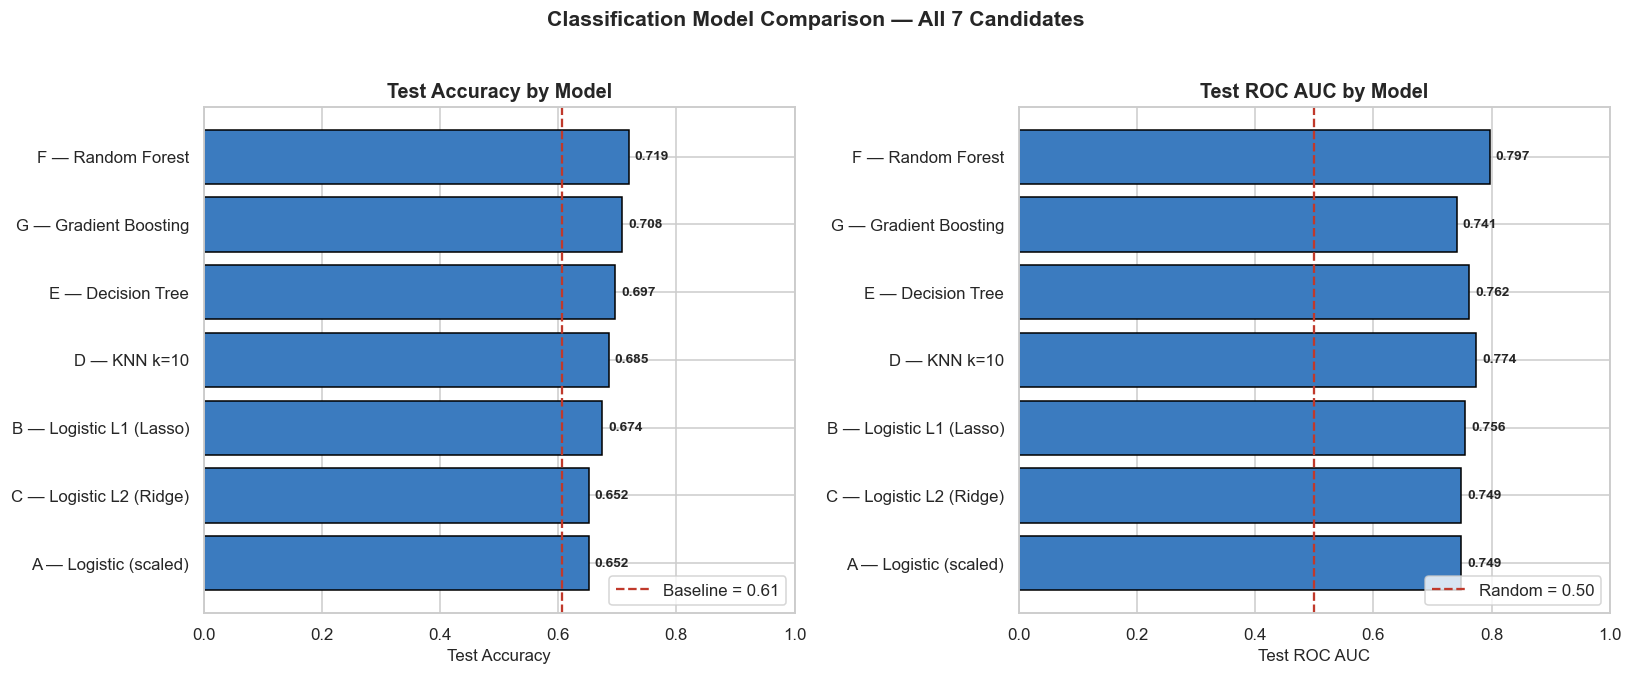

In [48]:
# Presentation-grade comparison chart: side-by-side test accuracy and ROC AUC
plot_df = display_df.sort_values('test_acc', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Test accuracy
colors_acc = [PALETTE['highlight'] if a > 0.75 else
              PALETTE['stable'] if a > BASELINE else
              PALETTE['neutral'] for a in plot_df['test_acc']]
axes[0].barh(plot_df['model'], plot_df['test_acc'], color=colors_acc, edgecolor='black')
axes[0].axvline(BASELINE, color=PALETTE['at_risk'], linestyle='--', linewidth=1.5,
                label=f'Baseline = {BASELINE:.2f}')
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Test Accuracy by Model')
axes[0].set_xlim(0, 1)
axes[0].legend(loc='lower right')
for i, v in enumerate(plot_df['test_acc']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

# ROC AUC
colors_auc = [PALETTE['highlight'] if a > 0.80 else
              PALETTE['stable'] if a > 0.65 else
              PALETTE['neutral'] for a in plot_df['test_auc']]
axes[1].barh(plot_df['model'], plot_df['test_auc'], color=colors_auc, edgecolor='black')
axes[1].axvline(0.5, color=PALETTE['at_risk'], linestyle='--', linewidth=1.5,
                label='Random = 0.50')
axes[1].set_xlabel('Test ROC AUC')
axes[1].set_title('Test ROC AUC by Model')
axes[1].set_xlim(0, 1)
axes[1].legend(loc='lower right')
for i, v in enumerate(plot_df['test_auc']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Classification Model Comparison — All 7 Candidates',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(base, 'figures', 'classification_model_comparison.png'),
            bbox_inches='tight') if os.path.isdir(os.path.join(base, 'figures')) else None
plt.show()

## 8. Multi-seed stability check on the winner
We refit the winning model across 10 different random_state values to verify the result is not luck of the split.

**Verdict thresholds:**
- Test accuracy std < 0.03 → STABLE
- Test accuracy std 0.03 to 0.05 → MODERATELY stable
- Test accuracy std > 0.05 → UNSTABLE

In [49]:
winner_idx = results_df['test_acc'].idxmax()
winner = results_df.loc[winner_idx]
winner_name = winner['model']

model_factory = {
    'A — Logistic (scaled)':     lambda: Pipeline([('scale', StandardScaler()), ('logreg', LogisticRegression(max_iter=2000, random_state=42))]),
    'B — Logistic L1 (Lasso)':   lambda: Pipeline([('scale', StandardScaler()), ('logreg', LogisticRegressionCV(Cs=10, cv=5, penalty='l1', solver='liblinear', max_iter=2000, random_state=42))]),
    'C — Logistic L2 (Ridge)':   lambda: Pipeline([('scale', StandardScaler()), ('logreg', LogisticRegressionCV(Cs=10, cv=5, penalty='l2', max_iter=2000, random_state=42))]),
    'D — KNN k=10':              lambda: Pipeline([('scale', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=10))]),
    'E — Decision Tree':         lambda: DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42),
    'F — Random Forest':         lambda: RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'G — Gradient Boosting':     lambda: GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
}

make_winner = model_factory[winner_name]

print(f'Winning model: {winner_name}')
print(f'Single-split test accuracy: {winner["test_acc"]:.4f}')
print(f'Single-split test AUC:      {winner["test_auc"]:.4f}\n')

stability_rows = []
for seed in range(10):
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
        df[features_full].copy(), df['displacement_risk'],
        test_size=0.20, random_state=seed, stratify=df['displacement_risk']
    )
    medians = Xs_tr.median()
    Xs_tr = Xs_tr.fillna(medians)
    Xs_te = Xs_te.fillna(medians)

    m = make_winner()
    m.fit(Xs_tr, ys_tr)
    train_acc = accuracy_score(ys_tr, m.predict(Xs_tr))
    test_acc  = accuracy_score(ys_te, m.predict(Xs_te))
    test_auc  = roc_auc_score(ys_te, m.predict_proba(Xs_te)[:, 1]) if hasattr(m, 'predict_proba') else np.nan
    stability_rows.append({'seed': seed, 'train_acc': train_acc,
                            'test_acc': test_acc, 'test_auc': test_auc})

stab_df = pd.DataFrame(stability_rows).round(4)
print(stab_df.to_string(index=False))

acc_mean = stab_df['test_acc'].mean()
acc_std  = stab_df['test_acc'].std()
auc_mean = stab_df['test_auc'].mean()
auc_std  = stab_df['test_auc'].std()

print(f'\nTest accuracy across 10 seeds:')
print(f'  Mean: {acc_mean:.4f}    Std: {acc_std:.4f}    Range: {stab_df["test_acc"].min():.3f}–{stab_df["test_acc"].max():.3f}')
print(f'Test AUC across 10 seeds:')
print(f'  Mean: {auc_mean:.4f}    Std: {auc_std:.4f}    Range: {stab_df["test_auc"].min():.3f}–{stab_df["test_auc"].max():.3f}')

if acc_std < 0.03:
    print('\nVERDICT: Model is STABLE across random splits. Result is reliable.')
elif acc_std < 0.05:
    print('\nVERDICT: Model is MODERATELY stable. Report mean accuracy with confidence interval.')
else:
    print('\nVERDICT: Model is UNSTABLE. Report mean and full range.')

Winning model: F — Random Forest
Single-split test accuracy: 0.7191
Single-split test AUC:      0.7968

 seed  train_acc  test_acc  test_auc
    0     0.8704    0.7753    0.8365
    1     0.8620    0.7079    0.8005
    2     0.8620    0.7865    0.8434
    3     0.8732    0.7640    0.8561
    4     0.8563    0.7303    0.8513
    5     0.8648    0.7191    0.7979
    6     0.8761    0.7191    0.8058
    7     0.8592    0.7753    0.8275
    8     0.8676    0.7528    0.8037
    9     0.8592    0.7640    0.8693

Test accuracy across 10 seeds:
  Mean: 0.7494    Std: 0.0280    Range: 0.708–0.786
Test AUC across 10 seeds:
  Mean: 0.8292    Std: 0.0260    Range: 0.798–0.869

VERDICT: Model is STABLE across random splits. Result is reliable.


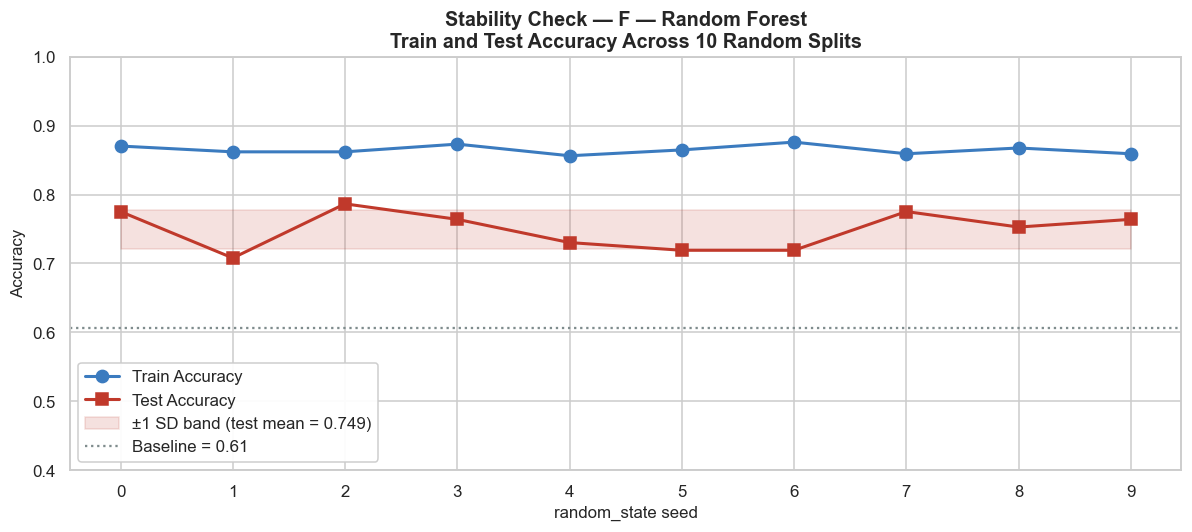

In [50]:
# Stability plot with shaded variance band
fig, ax = plt.subplots(figsize=(11, 5))
x = stab_df['seed']
ax.plot(x, stab_df['train_acc'], 'o-', label='Train Accuracy',
        color=PALETTE['stable'], linewidth=2, markersize=8)
ax.plot(x, stab_df['test_acc'], 's-', label='Test Accuracy',
        color=PALETTE['at_risk'], linewidth=2, markersize=8)
ax.fill_between(x, acc_mean - acc_std, acc_mean + acc_std,
                color=PALETTE['at_risk'], alpha=0.15,
                label=f'±1 SD band (test mean = {acc_mean:.3f})')
ax.axhline(BASELINE, color=PALETTE['neutral'], linestyle=':', linewidth=1.5,
           label=f'Baseline = {BASELINE:.2f}')
ax.set_xlabel('random_state seed')
ax.set_ylabel('Accuracy')
ax.set_title(f'Stability Check — {winner_name}\nTrain and Test Accuracy Across 10 Random Splits')
ax.legend(loc='lower left', framealpha=0.95)
ax.set_xticks(x)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

## 9. Confusion matrix and classification report
Refit the winning model and inspect its predictions on the test set in detail.

In [51]:
winner_fit = make_winner()
winner_fit.fit(X_train, y_train)
y_test_pred  = winner_fit.predict(X_test)
y_test_proba = winner_fit.predict_proba(X_test)[:, 1] if hasattr(winner_fit, 'predict_proba') else y_test_pred

cm = confusion_matrix(y_test, y_test_pred)
print(f'Confusion matrix for {winner_name}:\n')
print(f'                  Pred Stable  Pred At Risk')
print(f'Actual Stable     {cm[0,0]:>11d}  {cm[0,1]:>12d}')
print(f'Actual At Risk    {cm[1,0]:>11d}  {cm[1,1]:>12d}')
print(f'\nAccuracy: {accuracy_score(y_test, y_test_pred):.3f}')
print(f'\nClassification report:')
print(classification_report(y_test, y_test_pred,
                            target_names=['Stable', 'At Risk']))

Confusion matrix for F — Random Forest:

                  Pred Stable  Pred At Risk
Actual Stable              44            10
Actual At Risk             15            20

Accuracy: 0.719

Classification report:
              precision    recall  f1-score   support

      Stable       0.75      0.81      0.78        54
     At Risk       0.67      0.57      0.62        35

    accuracy                           0.72        89
   macro avg       0.71      0.69      0.70        89
weighted avg       0.71      0.72      0.71        89



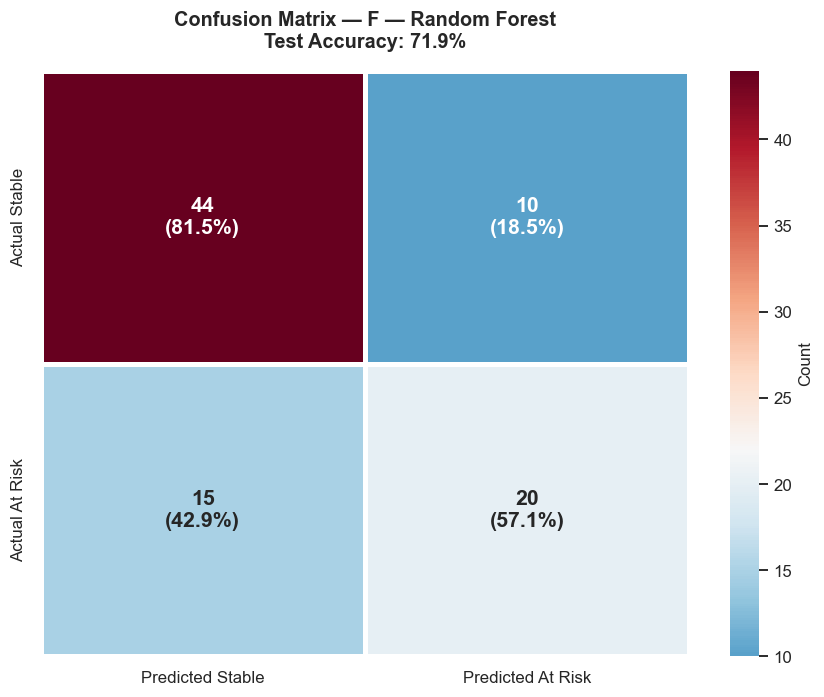

In [52]:
# Presentation-grade confusion matrix heatmap
fig, ax = plt.subplots(figsize=(8, 6.5))

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])

sns.heatmap(cm, annot=annot, fmt='', cmap='RdBu_r', center=cm.max()/2,
            xticklabels=['Predicted Stable', 'Predicted At Risk'],
            yticklabels=['Actual Stable', 'Actual At Risk'],
            cbar_kws={'label': 'Count'}, ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'},
            linewidths=2, linecolor='white')
ax.set_title(f'Confusion Matrix — {winner_name}\n'
             f'Test Accuracy: {accuracy_score(y_test, y_test_pred):.1%}',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 10. ROC Curve and Precision-Recall Curve
Two views of the model's threshold behavior. ROC shows the trade-off between true positive rate and false positive rate. PR shows precision vs recall, which is more informative when class balance is uneven.

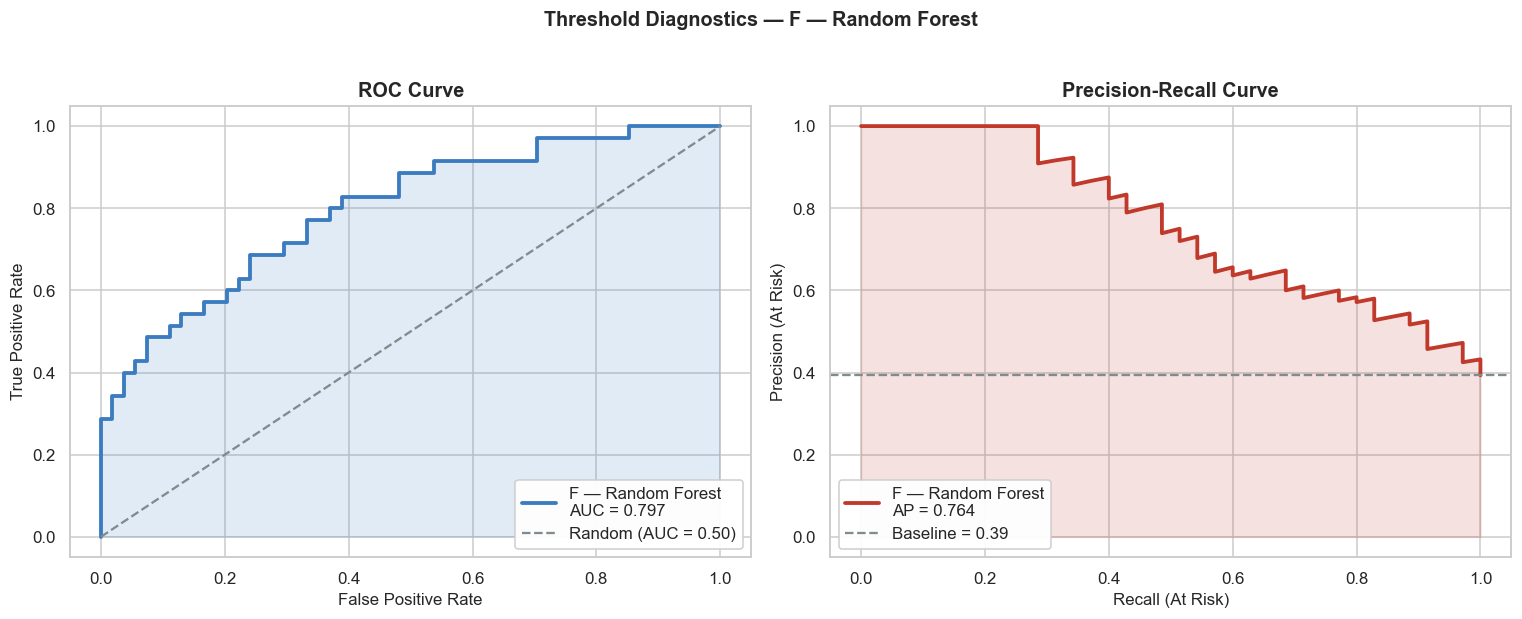

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)
axes[0].plot(fpr, tpr, color=PALETTE['stable'], linewidth=2.5,
             label=f'{winner_name}\nAUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], color=PALETTE['neutral'], linestyle='--',
             linewidth=1.5, label='Random (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.15, color=PALETTE['stable'])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right', framealpha=0.95)

# PR
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
ap = average_precision_score(y_test, y_test_proba)
axes[1].plot(recall, precision, color=PALETTE['at_risk'], linewidth=2.5,
             label=f'{winner_name}\nAP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color=PALETTE['neutral'], linestyle='--',
                linewidth=1.5, label=f'Baseline = {y_test.mean():.2f}')
axes[1].fill_between(recall, precision, alpha=0.15, color=PALETTE['at_risk'])
axes[1].set_xlabel('Recall (At Risk)')
axes[1].set_ylabel('Precision (At Risk)')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left', framealpha=0.95)

plt.suptitle(f'Threshold Diagnostics — {winner_name}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Feature importance and coefficient interpretation
Two complementary views depending on which model won.
- **For tree models:** built-in feature importance from impurity reduction.
- **For logistic models:** standardized coefficients (effect of a 1 SD increase) and odds ratios.

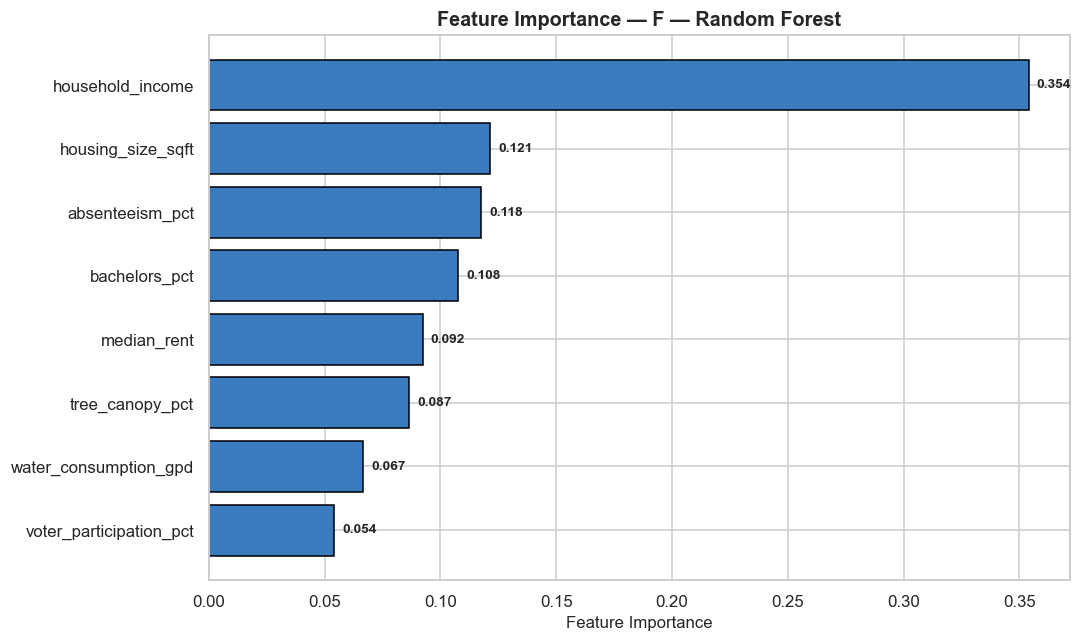

                feature  importance
voter_participation_pct      0.0539
  water_consumption_gpd      0.0665
        tree_canopy_pct      0.0866
            median_rent      0.0923
          bachelors_pct      0.1077
        absenteeism_pct      0.1177
      housing_size_sqft      0.1213
       household_income      0.3539


In [54]:
# Tree-based feature importance
tree_winner = any(name in winner_name for name in ['Random Forest', 'Gradient Boosting', 'Decision Tree'])

if tree_winner:
    if hasattr(winner_fit, 'feature_importances_'):
        importances = winner_fit.feature_importances_
    else:
        importances = winner_fit.named_steps[list(winner_fit.named_steps.keys())[-1]].feature_importances_
    fi_df = pd.DataFrame({
        'feature': features_full,
        'importance': importances
    }).sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(fi_df['feature'], fi_df['importance'],
                    color=PALETTE['stable'], edgecolor='black')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Feature Importance — {winner_name}', fontweight='bold')
    for i, v in enumerate(fi_df['importance']):
        ax.text(v + max(fi_df['importance']) * 0.01, i, f'{v:.3f}',
                va='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(fi_df.round(4).to_string(index=False))
else:
    # Logistic — extract scaled coefficients
    last_step = list(winner_fit.named_steps.keys())[-1]
    coefs = winner_fit.named_steps[last_step].coef_[0]
    coef_df = pd.DataFrame({
        'feature': features_full,
        'coef_std_units': coefs,
        'odds_ratio_per_1sd': np.exp(coefs),
    }).sort_values('coef_std_units', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [PALETTE['stable'] if c > 0 else PALETTE['at_risk'] for c in coef_df['coef_std_units']]
    ax.barh(coef_df['feature'], coef_df['coef_std_units'], color=colors, edgecolor='black')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Coefficient (effect of 1 SD increase on log-odds of At Risk)')
    ax.set_title(f'Logistic Coefficients — {winner_name}\n'
                 f'(blue = increases At Risk probability; red = decreases)',
                 fontweight='bold')
    for i, v in enumerate(coef_df['coef_std_units']):
        offset = 0.02 if v > 0 else -0.02
        ax.text(v + offset, i, f'{v:+.2f}', va='center', fontsize=9, fontweight='bold',
                ha='left' if v > 0 else 'right')
    plt.tight_layout()
    plt.show()
    print(coef_df.round(4).to_string(index=False))

## 12. Headline figure for the presentation
A single dashboard-style figure that summarizes the entire classification result. Use this slide for the 3-minute video.

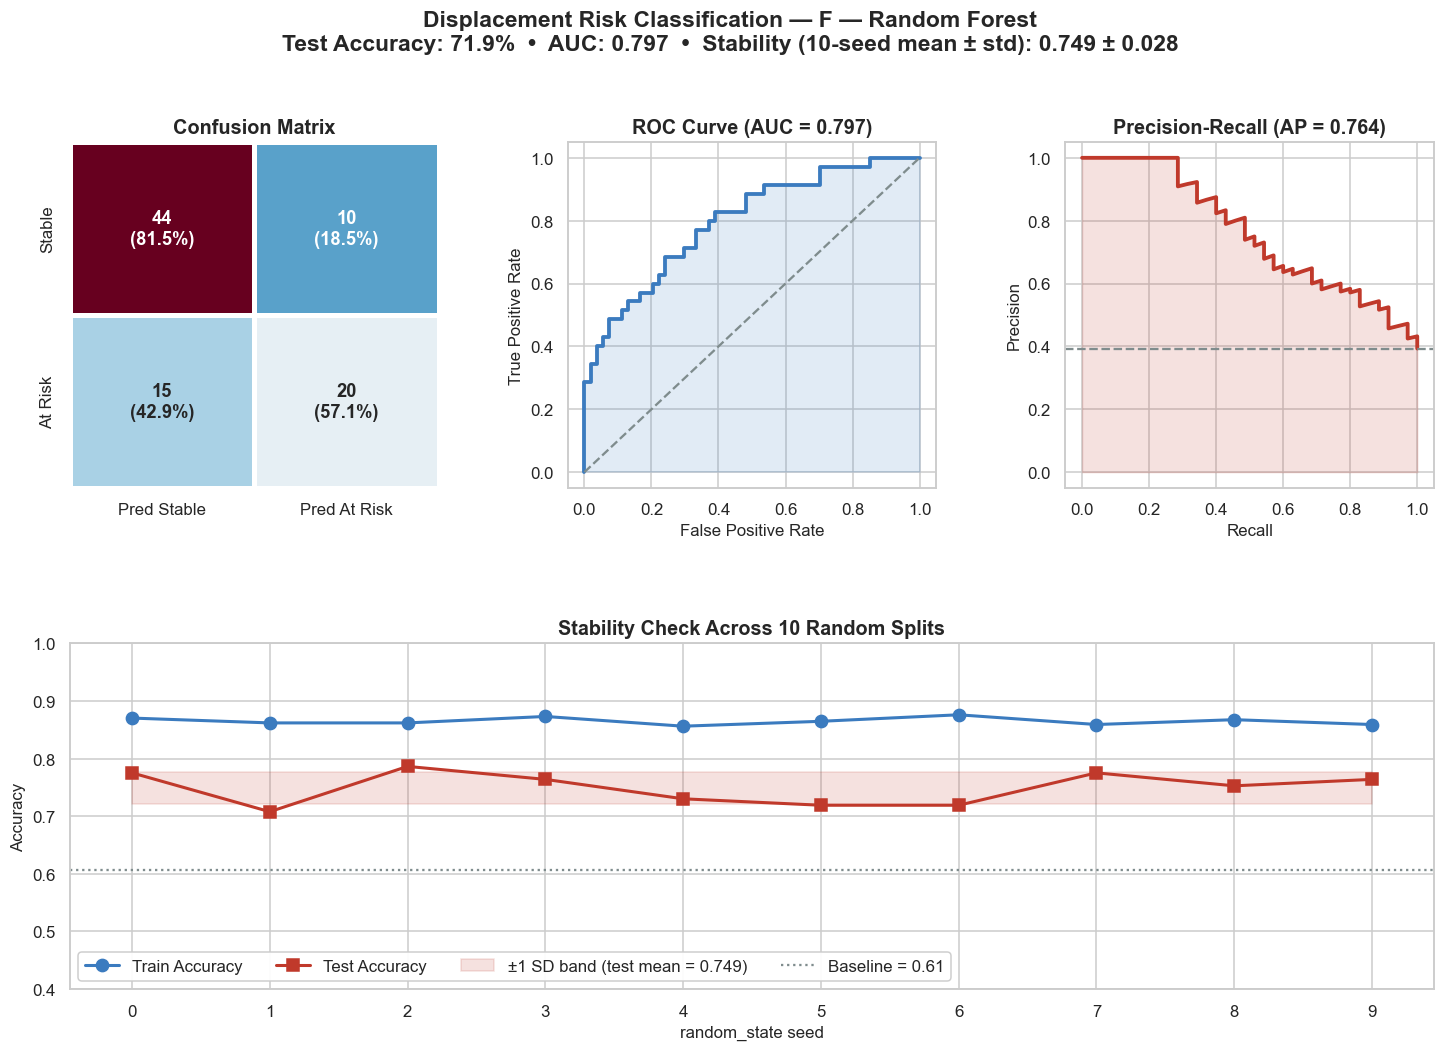

In [36]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# Top-left: confusion matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=annot, fmt='', cmap='RdBu_r', center=cm.max()/2,
            xticklabels=['Pred Stable', 'Pred At Risk'],
            yticklabels=['Stable', 'At Risk'],
            cbar=False, ax=ax1, annot_kws={'size': 12, 'weight': 'bold'},
            linewidths=2, linecolor='white')
ax1.set_title('Confusion Matrix', fontweight='bold')

# Top-middle: ROC
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fpr, tpr, color=PALETTE['stable'], linewidth=2.5)
ax2.plot([0, 1], [0, 1], color=PALETTE['neutral'], linestyle='--', linewidth=1.5)
ax2.fill_between(fpr, tpr, alpha=0.15, color=PALETTE['stable'])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title(f'ROC Curve (AUC = {auc:.3f})', fontweight='bold')

# Top-right: PR
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(recall, precision, color=PALETTE['at_risk'], linewidth=2.5)
ax3.axhline(y_test.mean(), color=PALETTE['neutral'], linestyle='--', linewidth=1.5)
ax3.fill_between(recall, precision, alpha=0.15, color=PALETTE['at_risk'])
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title(f'Precision-Recall (AP = {ap:.3f})', fontweight='bold')

# Bottom: stability
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(x, stab_df['train_acc'], 'o-', label='Train Accuracy',
         color=PALETTE['stable'], linewidth=2, markersize=8)
ax4.plot(x, stab_df['test_acc'], 's-', label='Test Accuracy',
         color=PALETTE['at_risk'], linewidth=2, markersize=8)
ax4.fill_between(x, acc_mean - acc_std, acc_mean + acc_std,
                 color=PALETTE['at_risk'], alpha=0.15,
                 label=f'±1 SD band (test mean = {acc_mean:.3f})')
ax4.axhline(BASELINE, color=PALETTE['neutral'], linestyle=':', linewidth=1.5,
            label=f'Baseline = {BASELINE:.2f}')
ax4.set_xlabel('random_state seed')
ax4.set_ylabel('Accuracy')
ax4.set_title('Stability Check Across 10 Random Splits', fontweight='bold')
ax4.legend(loc='lower left', framealpha=0.95, ncol=4)
ax4.set_xticks(x)
ax4.set_ylim(0.4, 1.0)

fig.suptitle(
    f'Displacement Risk Classification — {winner_name}\n'
    f'Test Accuracy: {accuracy_score(y_test, y_test_pred):.1%}  •  '
    f'AUC: {auc:.3f}  •  '
    f'Stability (10-seed mean ± std): {acc_mean:.3f} ± {acc_std:.3f}',
    fontsize=15, fontweight='bold', y=1.00
)
plt.show()

## 13. Save outputs to database

In [37]:
results_df.to_sql('classification_model_comparison', conn, if_exists='replace', index=False)
stab_df.to_sql('classification_stability_check', conn, if_exists='replace', index=False)

pred_df = pd.DataFrame({
    'npa_id': test_npa_ids,
    'actual_class': y_test.values,
    'predicted_class': y_test_pred,
    'predicted_proba_atrisk': y_test_proba,
})
pred_df.to_sql('classification_test_predictions', conn, if_exists='replace', index=False)

for tbl in ['classification_model_comparison', 'classification_stability_check',
            'classification_test_predictions']:
    n = pd.read_sql(f'SELECT COUNT(*) AS n FROM {tbl}', conn)['n'][0]
    print(f'{tbl}: {n} rows saved')

classification_model_comparison: 7 rows saved
classification_stability_check: 10 rows saved
classification_test_predictions: 89 rows saved


In [38]:
conn.close()
print('\nConnection closed. Classification notebook complete.')
print('\nNext steps:')
print('  1. Review outputs and confirm winning model is defensible.')
print('  2. Push to GitHub.')
print('  3. Build the report sections, video script, and code appendix.')


Connection closed. Classification notebook complete.

Next steps:
  1. Review outputs and confirm winning model is defensible.
  2. Push to GitHub.
  3. Build the report sections, video script, and code appendix.
